In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
noise = gpd.read_file("data/noise.zip")
transport_lines = gpd.read_file("data/transport_lines.zip")
metro_entrences = gpd.read_file("data/metro_entrences.zip")
roads = gpd.read_file("data/roads.zip")

In [3]:
noise

,DB_LO,DB_HI,SHAPE_LEN,geometry
0,5.0,10.0,7.617187e+05,"MULTIPOLYGON (((-733950.04 -1034130, -733950 -..."
1,10.0,15.0,8.163733e+05,"MULTIPOLYGON (((-733950.905 -1034130, -733950 ..."
2,15.0,20.0,8.648527e+05,"MULTIPOLYGON (((-733951.77 -1034130, -733950 -..."
3,20.0,25.0,9.233291e+05,"MULTIPOLYGON (((-733952.635 -1034130, -733950 ..."
4,25.0,30.0,1.016043e+06,"MULTIPOLYGON (((-733953.501 -1034130, -733950 ..."
5,30.0,35.0,1.280995e+06,"MULTIPOLYGON (((-733954.366 -1034130, -733950 ..."
6,35.0,40.0,2.186663e+06,"MULTIPOLYGON (((-733955.231 -1034130, -733950 ..."
7,40.0,45.0,3.608083e+06,"MULTIPOLYGON (((-733956.097 -1034130, -733950 ..."
8,45.0,50.0,4.391242e+06,"MULTIPOLYGON (((-733956.962 -1034130, -733950 ..."
9,50.0,55.0,4.295783e+06,"MULTIPOLYGON (((-733957.827 -1034130, -733950 ..."


In [4]:
noise_bounds = noise.unary_union

C:\Users\kajet\AppData\Local\Temp\ipykernel_20488\4229401385.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  noise_bounds = noise.unary_union


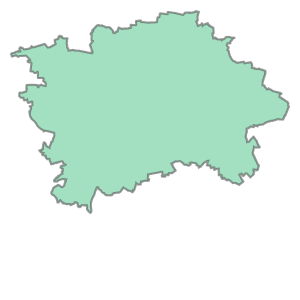

In [5]:
noise_bounds

In [31]:
districts = gpd.read_file('data/DISTRICTS.zip')

In [32]:
districts

,KOD_MC,NAZEV_MC,POSKYT,ID_POSKYT,STAV_ZMENA,NAZEV_1,SHAPE_LEN,geometry
0,547310,Praha-Čakovice,HMP-IPR,43,U,Čakovice,18510.070815,"POLYGON ((-733164.1 -1037426.87, -733137.03 -1..."
1,547361,Praha 14,HMP-IPR,43,U,Praha 14,21694.540480,"POLYGON ((-731854.76 -1043020.35, -731825.29 -..."
2,547107,Praha 12,HMP-IPR,43,U,Praha 12,28249.410323,"POLYGON ((-741841.95 -1052678.55, -741838.85 -..."
3,547174,Praha 17,HMP-IPR,43,U,Praha 17,7936.181063,"POLYGON ((-752038.72 -1042852.14, -752039.5 -1..."
4,547298,Praha-Ďáblice,HMP-IPR,43,U,Ďáblice,14957.953038,"POLYGON ((-739567.3 -1037894.61, -739567 -1037..."
5,500224,Praha 10,HMP-IPR,43,U,Praha 10,27422.478441,"POLYGON ((-736577.91 -1046843.85, -736578.73 -..."
6,539724,Praha-Šeberov,HMP-IPR,43,U,Šeberov,12935.445949,"POLYGON ((-737677.83 -1054367.15, -737678.45 -..."
7,539791,Praha-Újezd,HMP-IPR,43,U,Újezd,9381.623830,"POLYGON ((-735846.1 -1052465.11, -735849.83 -1..."
8,547051,Praha-Libuš,HMP-IPR,43,U,Libuš,17091.236023,"POLYGON ((-741222.45 -1055178.83, -741222.88 -..."
9,538124,Praha-Březiněves,HMP-IPR,43,U,Březiněves,10544.899114,"POLYGON ((-738951.42 -1035512.67, -738940.86 -..."


In [33]:
city_boundary = districts.unary_union

C:\Users\kajet\AppData\Local\Temp\ipykernel_19652\464000106.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_boundary = districts.unary_union


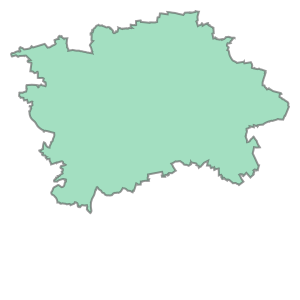

In [52]:
city_boundary

In [140]:
city_boundary_gdf = gpd.GeoDataFrame({'geometry': [city_boundary]})

In [141]:
city_boundary_gdf

,geometry
0,"POLYGON ((-748375.81 -1057864.07, -748395.36 -..."


In [59]:
districts.set_geometry('geometry', inplace=True)

In [8]:
import numpy as np

In [128]:
G = np.random.choice(districts.geometry.values)
print(G)

POLYGON ((14.574616984551954 50.1081679676149, 14.574536360937083 50.108347033626444, 14.574517186234578 50.10838982147577, 14.57450049752514 50.10842683763317, 14.574459058550476 50.10851903974157, 14.574403958545703 50.10863790615001, 14.574250850296615 50.10875521668995, 14.574222442648326 50.10877687563022, 14.574218228110208 50.108780137606566, 14.574190135064628 50.10880164249625, 14.574148064719175 50.108833905855626, 14.574094578221478 50.10887079960485, 14.573968769585122 50.10895764403633, 14.573963064055544 50.10896195557672, 14.574039087671634 50.10897075946935, 14.57412694611915 50.10898231875857, 14.574676196215327 50.10905459716152, 14.575343227326133 50.10914239988903, 14.57556369694433 50.109171412514385, 14.575570605413548 50.10930266951943, 14.575570972523918 50.10930896206162, 14.575571555315285 50.10933097014013, 14.575574875985271 50.10946318472837, 14.575581510939536 50.10973233142564, 14.575582317790902 50.10976198056468, 14.575588301369569 50.11000475802086, 14

In [9]:
from shapely.ops import split
import geopandas
from shapely.geometry import MultiPolygon, Polygon
from shapely.geometry import LineString

def get_squares_from_rect(RectangularPolygon, side_length=0.0025):
    """
    Divide a Rectangle (Shapely Polygon) into squares of equal area.

    `side_length` : required side of square

    """
    rect_coords = np.array(RectangularPolygon.boundary.coords.xy)
    y_list = rect_coords[1]
    x_list = rect_coords[0]
    y1 = min(y_list)
    y2 = max(y_list)
    x1 = min(x_list)
    x2 = max(x_list)
    width = x2 - x1
    height = y2 - y1

    xcells = int(np.round(width / side_length))
    ycells = int(np.round(height / side_length))

    yindices = np.linspace(y1, y2, ycells + 1)
    xindices = np.linspace(x1, x2, xcells + 1)
    horizontal_splitters = [
        LineString([(x, yindices[0]), (x, yindices[-1])]) for x in xindices
    ]
    vertical_splitters = [
        LineString([(xindices[0], y), (xindices[-1], y)]) for y in yindices
    ]
    result = RectangularPolygon
    for splitter in vertical_splitters:
        result = MultiPolygon(split(result, splitter))
    for splitter in horizontal_splitters:
        result = MultiPolygon(split(result, splitter))
    square_polygons = list(result.geoms)

    return square_polygons


def split_polygon(G, side_length=0.025, thresh=0.9):
    """
    Using a rectangular envelope around `G`, creates a mesh of squares of required length.
    
    Removes non-intersecting polygons. 
            

    Args:
    
    - `thresh` : Range - [0,1]

        This controls - the number of smaller polygons at the boundaries.
        
        A thresh == 1 will only create (or retain) smaller polygons that are 
        completely enclosed (area of intersection=area of smaller polygon) 
        by the original Geometry - `G`.
        
        A thresh == 0 will create (or retain) smaller polygons that 
        have a non-zero intersection (area of intersection>0) with the
        original geometry - `G` 

    - `side_length` : Range - (0,infinity)
        side_length must be such that the resultant geometries are smaller 
        than the original geometry - `G`, for a useful result.

        side_length should be >0 (non-zero positive)

    - `shape` : {square/rhombus}
        Desired shape of subset geometries. 


    """
    assert side_length>0, "side_length must be a float>0"
    Rectangle    = G.envelope
    squares      = get_squares_from_rect(Rectangle, side_length=side_length)
    SquareGeoDF  = geopandas.GeoDataFrame(squares).rename(columns={0: "geometry"})
    SquareGeoDF.set_geometry('geometry', inplace=True)
    Geoms        = SquareGeoDF[SquareGeoDF.intersects(G)].geometry.values
    geoms = [g for g in Geoms if ((g.intersection(G)).area / g.area) >= thresh]
    return geoms




In [23]:

squares   = split_polygon(noise_bounds,thresh=0.01,side_length=1000)
squares = geopandas.GeoDataFrame(squares).rename(columns={0: "geometry"})
squares.set_geometry('geometry', inplace=True)


In [24]:
squares

,geometry
0,"POLYGON ((-746538.794 -1058799.957, -747537.90..."
1,"POLYGON ((-747537.908 -1058799.957, -748537.02..."
2,"POLYGON ((-751534.366 -1056825.564, -750535.25..."
3,"POLYGON ((-750535.252 -1056825.564, -749536.13..."
4,"POLYGON ((-749536.137 -1056825.564, -748537.02..."
...,...
566,"POLYGON ((-738545.878 -1034120.04, -737546.764..."
567,"POLYGON ((-737546.764 -1034120.04, -736547.65 ..."
568,"POLYGON ((-736547.65 -1034120.04, -735548.535 ..."
569,"POLYGON ((-735548.535 -1034120.04, -734549.421..."


In [26]:
noise_bounds_gdf = gpd.GeoDataFrame(geometry=[noise_bounds])  # Set an appropriate CRS

C:\Users\kajet\AppData\Local\Temp\ipykernel_20488\3636936397.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


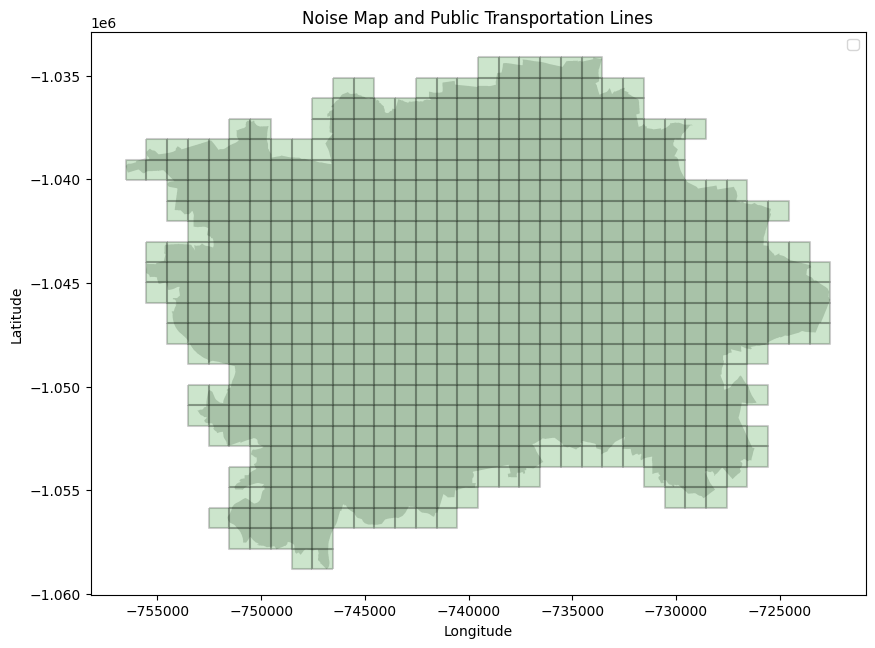

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the noise map
#noise.plot(ax=ax, color="lightgray", edgecolor="black", label="Noise Map")
noise_bounds_gdf.plot(ax=ax, alpha = 1, color="lightgray")

# Plot the public transportation lines
squares.plot(ax=ax, alpha = 0.2, color="green",edgecolor="black", linewidth=1.5)

# Add a legend
ax.legend()

# Add title and labels
ax.set_title("Noise Map and Public Transportation Lines")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Show the map
plt.show()

In [194]:
city_boundary_gdf.dtypes

geometry    geometry
dtype: object

In [185]:
squares   = split_polygon(city_boundary, shape='square',thresh=0.01, side_length=1500)
squares = geopandas.GeoDataFrame(squares).rename(columns={0: "geometry"})
squares.set_geometry('geometry', inplace=True)

C:\Users\kajet\AppData\Local\Temp\ipykernel_19652\183786795.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


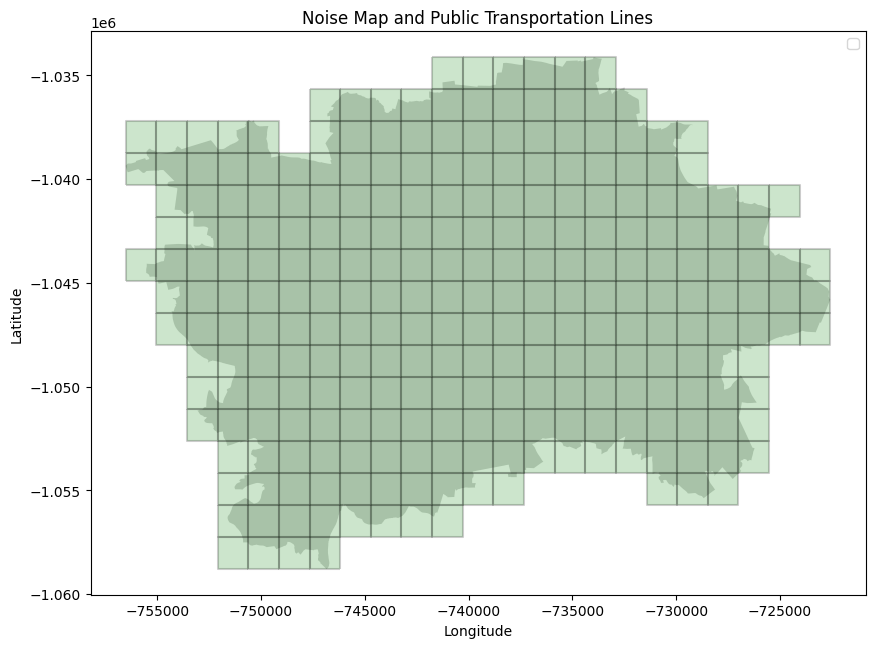

In [186]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the noise map
#noise.plot(ax=ax, color="lightgray", edgecolor="black", label="Noise Map")
city_boundary_gdf.plot(ax=ax, alpha = 1, color="lightgray")

# Plot the public transportation lines
squares.plot(ax=ax, alpha = 0.2, color="green",edgecolor="black", linewidth=1.5)

# Add a legend
ax.legend()

# Add title and labels
ax.set_title("Noise Map and Public Transportation Lines")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Show the map
plt.show()

In [191]:
squares

,geometry
0,POLYGON ((-746187.4291304341 -1058799.60000000...
1,POLYGON ((-747663.5678260861 -1058799.60000000...
2,POLYGON ((-749139.7065217382 -1058799.60000000...
3,POLYGON ((-750615.8452173902 -1058799.60000000...
4,POLYGON ((-752091.9839130423 -1055715.05750000...
...,...
257,POLYGON ((-740282.8743478258 -1034123.26000000...
258,POLYGON ((-738806.7356521736 -1034123.26000000...
259,POLYGON ((-737330.5969565216 -1034123.26000000...
260,POLYGON ((-735854.4582608695 -1034123.26000000...


In [28]:
squares.to_csv('data/podzial_na_obrazki2.csv', index=False)

In [193]:
squares.dtypes

geometry    object
dtype: object